
# Fashion-MNIST (CSV) — Aula completa de classificação de imagens 

## Objetivos
- Trabalhar com dataset Fashion-MNIST
- Entender estrutura tabular de imagens
- Separar X e y
- Reconstruir imagens (28x28)
- Treinar modelo de classificação
- Avaliar desempenho


## 1. Bibliotecas

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



## 2. Carregar CSV

In [2]:

train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

print(train_df.shape)
print(test_df.shape)


(60000, 785)
(10000, 785)


## 3. Estrutura dos dados

In [3]:

train_df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Cada linha:
- coluna 0 → label
- colunas 1–784 → pixels


## 4. Separar X e y

In [4]:

y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(60000, 784) (60000,)
(10000, 784) (10000,)


## 5. Visualizar imagem

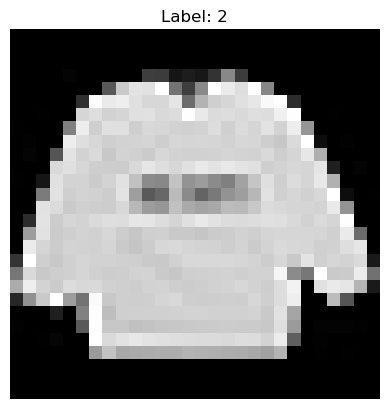

In [5]:

img = X_train[0].reshape(28,28) # índice muda a imagem

plt.imshow(img, cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


## 6. Normalização

In [6]:

X_train = X_train / 255.0
X_test = X_test / 255.0


## 7. Modelo

In [7]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 8. Avaliação

In [8]:

print("Acurácia:", accuracy_score(y_test, y_pred))


Acurácia: 0.8523


In [9]:

print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1000
           1       0.95      0.97      0.96      1000
           2       0.77      0.76      0.76      1000
           3       0.86      0.86      0.86      1000
           4       0.78      0.80      0.79      1000
           5       0.93      0.91      0.92      1000
           6       0.65      0.60      0.62      1000
           7       0.90      0.91      0.91      1000
           8       0.94      0.94      0.94      1000
           9       0.93      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



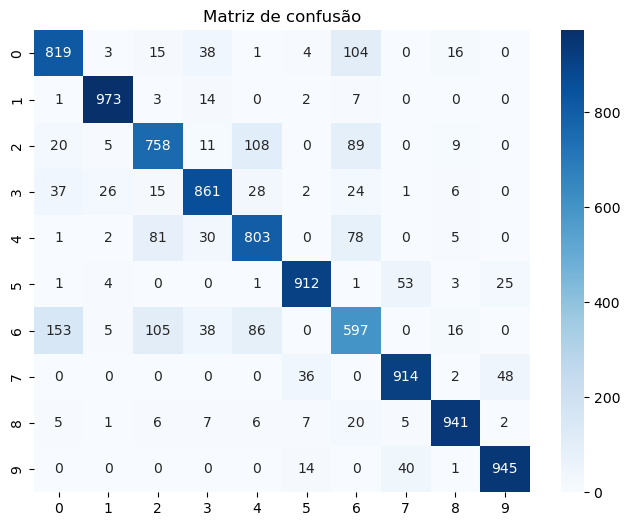

In [10]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusão")
plt.show()
